<a href="https://colab.research.google.com/github/newton143/SemesterProject/blob/main/ProjectMap_Version3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

In [ ]:
def fetch_acs_poverty_income(year,save_path):
    """Fetch ACS subject table data for ZCTAs and return a cleaned DataFrame."""
    BASE_URL = f"https://api.census.gov/data/{year}/acs/acs5/subject"

    params = {
        "get": "S1701_C03_001E,S1901_C01_012E,NAME",
        "for": "zip code tabulation area:*"
    }

    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json()

    # Convert to DataFrame
    df = pd.DataFrame(data[1:], columns=data[0])

    # Rename fields
    df = df.rename(columns={
        "S1701_C03_001E": "poverty_rate",
        "S1901_C01_012E": "median_income",
        "zip code tabulation area": "zcta"
    })

    # Convert numeric fields
    df["poverty_rate"] = pd.to_numeric(df["poverty_rate"], errors="coerce")
    df["median_income"] = pd.to_numeric(df["median_income"], errors="coerce")

    # Keep only necessary fields
    df = df[["zcta", "poverty_rate", "median_income"]]

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Saved CSV to {save_path}")

    return df

In [ ]:
# =========================================================
# 1. LOADERS
# =========================================================

def load_state_boundaries(state_shp_path):
    """Load US state boundaries."""
    states = gpd.read_file(state_shp_path)
    return states[states["NAME"].isin(["Nebraska", "Iowa"])]

def load_loans(loans_path):
    """Load NEF loans and clean ZIP codes."""
    df = pd.read_csv(loans_path)
    df.columns = df.columns.str.strip()

    df["zip"] = (
        df["zip"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d{5})")[0]
        .str.zfill(5)
    )
    df = df.dropna(subset=["zip"])
    return df

def load_zip_crosswalk(xwalk_path):
    """Load ZIP → COUNTY crosswalk (filter NE & IA)."""
    df = pd.read_csv(xwalk_path, dtype=str)
    df = df[df["USPS_ZIP_PREF_STATE"].isin(["NE", "IA"])]
    df["ZIP"] = df["ZIP"].str.zfill(5)

    # Pick primary county per ZIP (highest TOT_RATIO)
    df = (
        df.sort_values("TOT_RATIO", ascending=False)
          .groupby("ZIP")
          .first()
          .reset_index()[["ZIP", "COUNTY"]]
    )
    return df

def load_acs_poverty_income(acs_path):
    """Load ZIP-level ACS poverty + median income."""
    df = pd.read_csv(acs_path)
    df["zcta"] = df["zcta"].astype(str).str.zfill(5)
    return df

def load_county_shapes(ne_shp, ia_shp):
    """Load Nebraska + Iowa county-level shapefiles."""
    ne = gpd.read_file(ne_shp)
    ia = gpd.read_file(ia_shp)
    combined = pd.concat([ne, ia], ignore_index=True)
    return gpd.GeoDataFrame(combined, crs=ne.crs)

In [ ]:
# =========================================================
# 2. MERGE FUNCTIONS
# =========================================================

def merge_loans_with_counties(loans, zip_primary):
    """Add county to loan records."""
    return loans.merge(zip_primary, left_on="zip", right_on="ZIP", how="left")

def merge_acs_with_counties(acs, zip_primary):
    """Add county to ACS ZIP-level data."""
    return acs.merge(zip_primary, left_on="zcta", right_on="ZIP", how="left")


In [ ]:
# =========================================================
# 3. AGGREGATION FUNCTIONS
# =========================================================

def aggregate_loans_by_county(loans_with_county):
    return (
        loans_with_county.groupby("COUNTY")
        .size()
        .reset_index(name="loan_count")
    )

def aggregate_acs_by_county(acs_with_county):
    return (
        acs_with_county.groupby("COUNTY")
        .agg({
            "poverty_rate": "mean",
            "median_income": "mean"
        })
        .reset_index()
    )

def merge_county_stats(county_acs, county_loans):
    df = county_acs.merge(county_loans, on="COUNTY", how="left")
    df["loan_count"] = df["loan_count"].fillna(0)
    return df

def merge_stats_with_shapes(county_geo, stats):
    merged = county_geo.merge(
        stats,
        left_on="GEOID",
        right_on="COUNTY",
        how="left"
    )
    merged["loan_count"] = merged["loan_count"].fillna(0)
    merged["poverty_rate"] = merged["poverty_rate"].fillna(0)
    merged["median_income"] = merged["median_income"].fillna(0)
    return merged

In [ ]:
# =========================================================
# 4. VISUALIZATION
# =========================================================

def plot_heatmaps(region_merged):
    """Create 3 side-by-side heatmaps: poverty, income, loan count."""
    fig, ax = plt.subplots(1, 3, figsize=(20, 8))

    # Poverty Rate
    region_merged.plot(
        column="poverty_rate",
        cmap="Reds",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        ax=ax[0]
    )
    ax[0].set_title("ACS Poverty Rate (%)")

    # Median Income
    region_merged.plot(
        column="median_income",
        cmap="Blues",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        ax=ax[1]
    )
    ax[1].set_title("Median Household Income ($)")

    # Loan Count
    region_merged.plot(
        column="loan_count",
        cmap="Greens",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        ax=ax[2]
    )
    ax[2].set_title("NEF Loan Count")

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# 5. MAIN PIPELINE
# =========================================================

def main():
    # ---- File Paths ----
    projet_dir = r"C:/Python/DS/Project"
    download_dir = r"C:/Users/prabh/Downloads"  # centralize external downloaded shapefiles
    state_shp_path = os.path.join(download_dir, "tl_2024_us_state", "tl_2024_us_state.shp")
    loans_path = os.path.join(projet_dir, "NEF Loans.csv")
    xwalk_path = os.path.join(projet_dir, "ZIP_COUNTY_062025.csv")
    acs_path = os.path.join(projet_dir, "acs_poverty_income.csv")
    ne_shp = os.path.join(download_dir, "tl_2024_31_cousub", "tl_2024_31_cousub.shp")
    ia_shp = os.path.join(download_dir, "tl_2024_19_cousub", "tl_2024_19_cousub.shp")
    save_path = os.path.join(projet_dir, "acs_poverty_income.csv")
    year = "2022"

    # ---- Load Data ----
    print("Loading data...")
    fetch_acs_poverty_income(year, save_path)
    loans = load_loans(loans_path)
    zip_primary = load_zip_crosswalk(xwalk_path)
    acs = load_acs_poverty_income(acs_path)
    county_shapes = load_county_shapes(ne_shp, ia_shp)

    # ---- Merge ZIP → County ----
    loans_with_county = merge_loans_with_counties(loans, zip_primary)
    acs_with_county = merge_acs_with_counties(acs, zip_primary)

    # ---- Aggregate ----
    county_loans = aggregate_loans_by_county(loans_with_county)
    county_acs = aggregate_acs_by_county(acs_with_county)
    county_stats = merge_county_stats(county_acs, county_loans)

    # ---- County-level GIS Merge ----
    region_merged = merge_stats_with_shapes(county_shapes, county_stats)

    # ---- Visual Output ----
    print("Generating heatmaps...")
    plot_heatmaps(region_merged)

    print("Done! Heatmaps created successfully.")

Loading data...
Generating heatmaps...
Generating heatmaps...


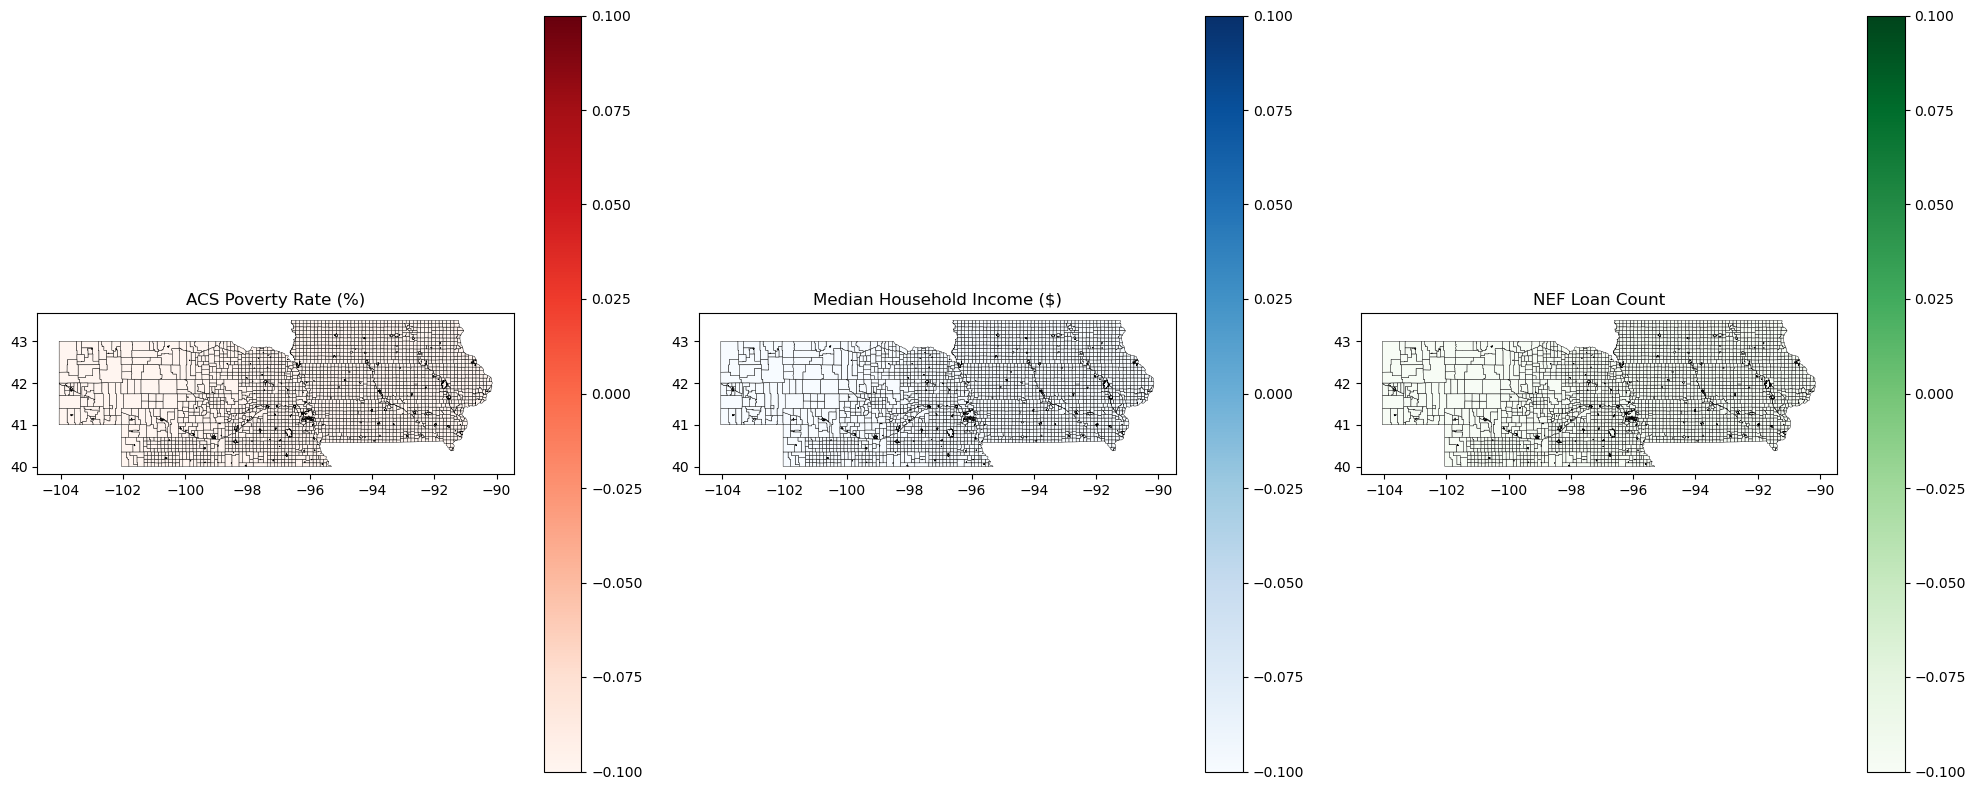

Done! Heatmaps created successfully.


In [ ]:
if __name__ == "__main__":
    main()